#### R2P Program Unit 3: Lesson 2
# Combine error mitigation options with the Estimator primitive

*Estimated QPU usage: 13 minutes (tested on IBM Fez)*

## Background

In this notebook, you'll explore the error suppression and error mitigation options available with the Estimator primitive from Qiskit Runtime. You will construct a circuit and observable and submit jobs using the Estimator primitive using different combinations of error mitigation settings. Then, you will plot the results to observe the effects of the various settings. Most of the notebook uses a 10-qubit circuit to make visualizations easier, and at the end, you can scale up the workflow to 50 qubits.

These are the error suppression and mitigation options you will use:

* Dynamical decoupling
* Measurement error mitigation
* Gate twirling
* Zero-noise extrapolation (ZNE)

## Requirements

Before starting this notebook, ensure that you have the following installed:

* Qiskit SDK 2.1 or later with visualization support (`pip install 'qiskit[visualization]'`)
* Qiskit Runtime 0.40 or later (`pip install qiskit-ibm-runtime`)


## Step 1. Map classical inputs to a quantum problem

This notebook assumes that the classical problem has already been mapped to quantum. Begin by constructing a circuit and observable to measure. While the techniques used in this notebook apply to many different kinds of circuits, for simplicity this notebook uses the [`efficient_su2`](https://quantum.cloud.ibm.com/docs/en/api/qiskit/qiskit.circuit.library.efficient_su2) circuit included in Qiskit's circuit library.

`efficient_su2` is a parameterized quantum circuit designed to be efficiently executable on quantum hardware with limited qubit connectivity, while still being expressive enough to solve problems in application domains like optimization and chemistry. It's built by alternating layers of parameterized single-qubit gates with a layer containing a fixed pattern of two-qubit gates, for a chosen number of repetitions. The pattern of two-qubit gates can be specified by the user. Here you can use the built-in `pairwise` pattern because it minimizes the circuit depth by packing the two-qubit gates as densely as possible. This pattern can be executed using only linear qubit connectivity.


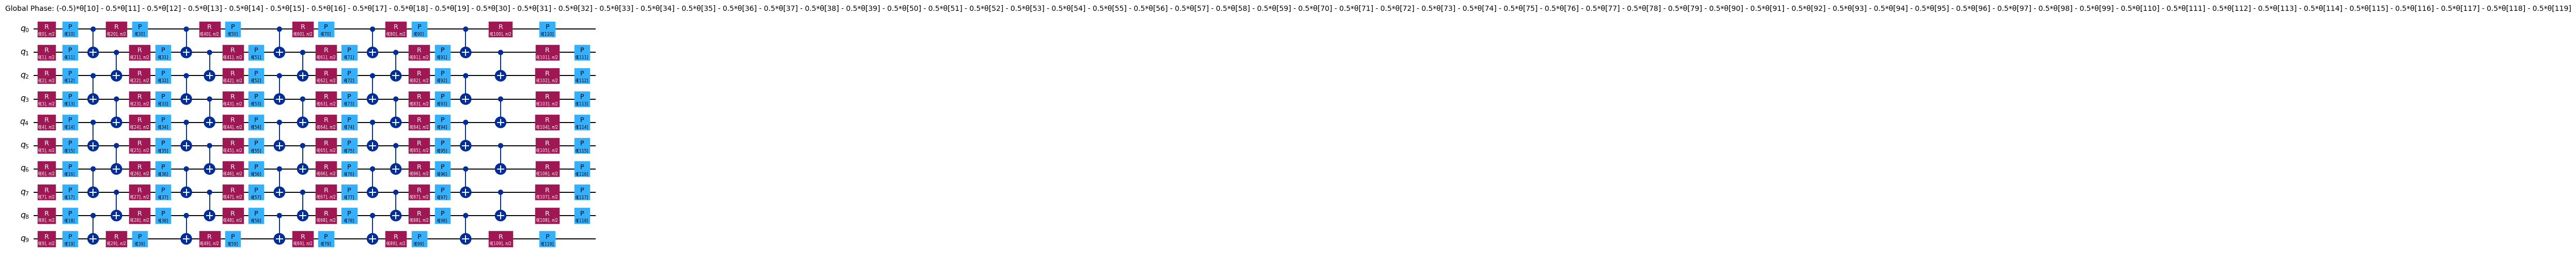

In [1]:
# Create a circuit that implements the Efficient SU2 ansatz with 10 qubits, 1 repetition and pairwise entanglement.

from qiskit.circuit.library import efficient_su2

circuit = efficient_su2(num_qubits=10, reps=5, entanglement='pairwise')

circuit.decompose().draw("mpl", scale=0.7)

For our observable, let's take the Pauli $Z$ operator acting on the first qubit, $I I \cdots I Z$.

In [2]:
# Create an observable where there is a Z on qubit 0 with coefficient 1.0
from qiskit.quantum_info import SparsePauliOp

num_qubits = 10
pauli_string = 'I' * (num_qubits - 1) + 'Z'
observable = SparsePauliOp(pauli_string)
print(observable)


SparsePauliOp(['IIIIIIIIIZ'],
              coeffs=[1.+0.j])


At this point, you could proceed to run your circuit and measure the observable. However, you also want to compare the output of the quantum device with the correct answer - that is, the theoretical value of the observable, if the circuit had been executed without error. For small quantum circuits you can calculate this value by simulating the circuit on a classical computer, but this is not possible for larger, utility-scale circuits. You can work around this issue with the "mirror circuit" technique (also known as "compute-uncompute"), which is useful for benchmarking the performance of quantum devices.

#### Mirror circuit

In the mirror circuit technique, you concatenate the circuit with its inverse circuit, which is formed by inverting each gate of the circuit in reverse order. The resulting circuit implements the identity operator, which can trivially be simulated. Because the structure of the original circuit is preserved in the mirror circuit, executing the mirror circuit still gives an idea of how the quantum device would perform on the original circuit.

The following code cell assigns random parameters to your circuit, and then constructs the mirror circuit using the [`unitary_overlap`](https://quantum.cloud.ibm.com/docs/en/api/qiskit/qiskit.circuit.library.unitary_overlapp) class. Before mirroring the circuit, append a [barrier](https://docs.quantum.ibm.com/api/qiskit/qiskit.circuit.library.Barrier#barrier) instruction to it to prevent the transpiler from merging the two parts of the circuit on either side of the barrier. Without the barrier, the transpiler would merge the original circuit with its inverse, resulting in a transpiled circuit without any gates.


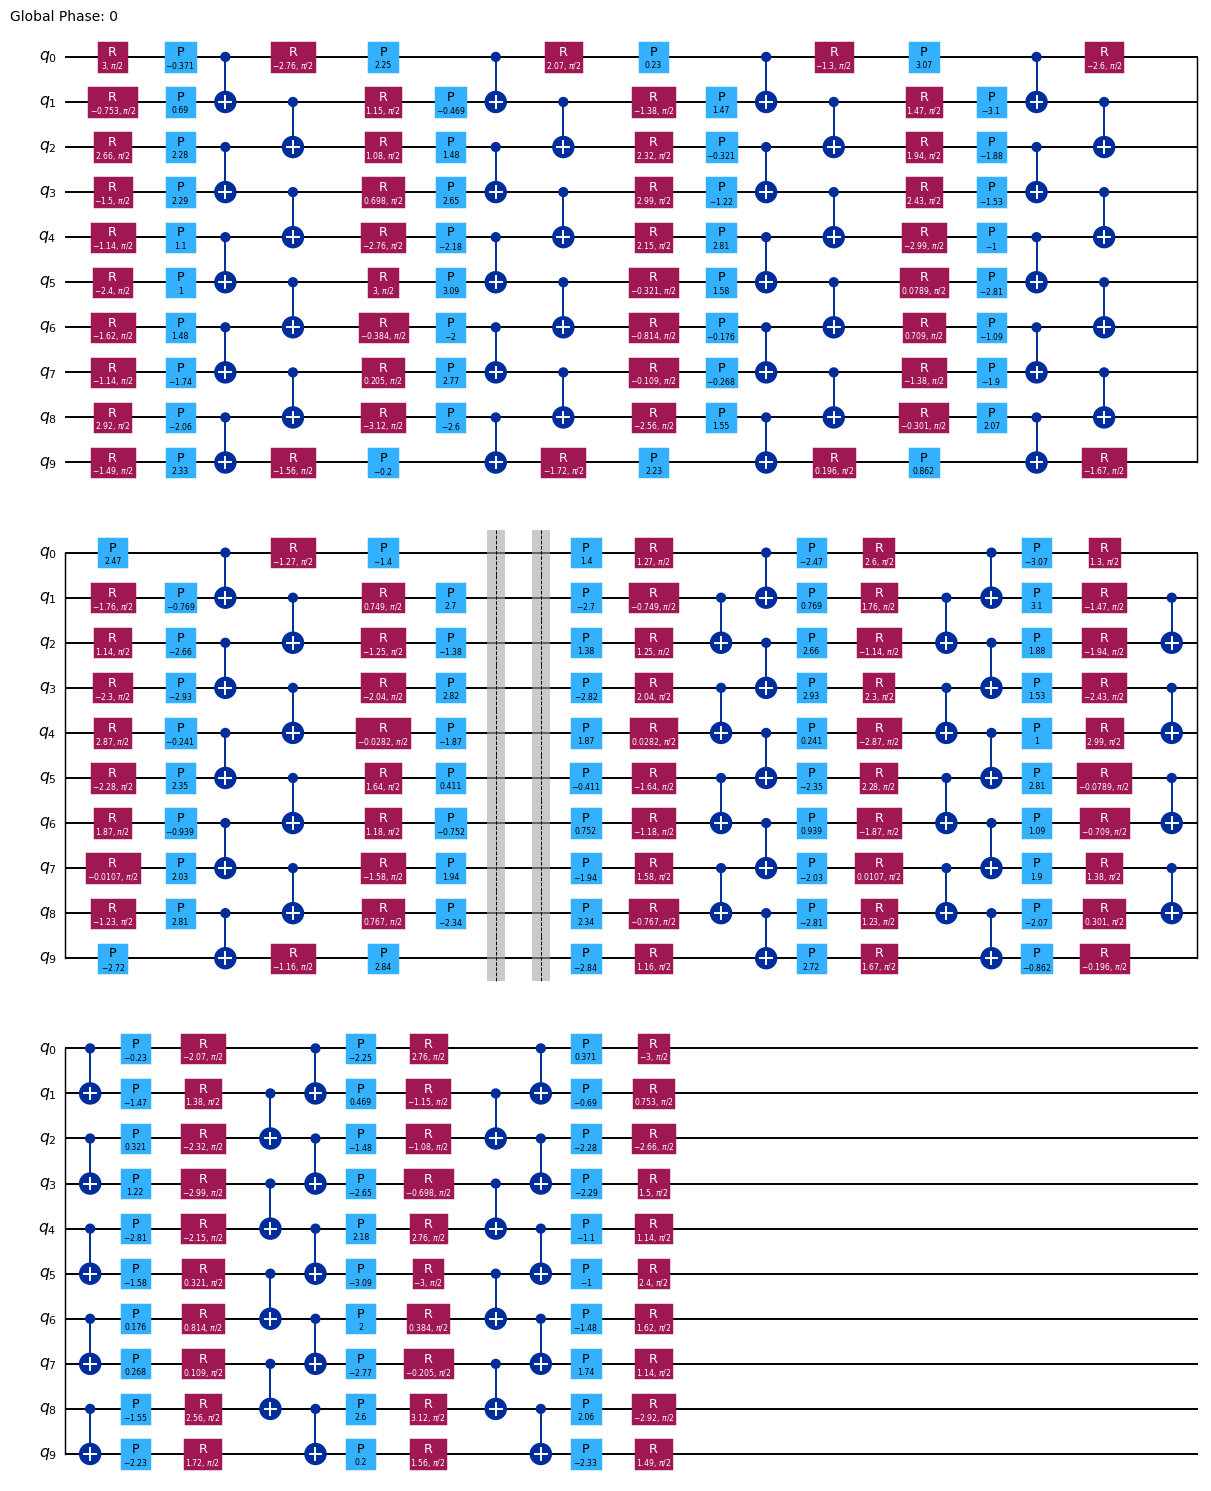

In [3]:
import numpy as np
from qiskit.circuit.library import unitary_overlap

# Generate random parameters
rng = np.random.default_rng(1234)
params = rng.uniform(-np.pi, np.pi, size=circuit.num_parameters)

# Assign the parameters to the circuit
assigned_circuit = circuit.assign_parameters(params)

# Add a barrier to prevent circuit optimization of mirrored operators
assigned_circuit.barrier()

# Construct mirror circuit
mirror_circuit = unitary_overlap(assigned_circuit, assigned_circuit)

mirror_circuit.decompose().draw("mpl", scale=0.7)

## Step 2: Optimize circuits for quantum hardware execution

You must optimize your circuit before running it on hardware. This process involves a few steps:

* Pick a qubit layout that maps the virtual qubits of your circuit to physical qubits on the hardware.
* Insert swap gates as needed to route interactions between qubits that are not connected.
* Translate the gates in your circuit to [Instruction Set Architecture (ISA)](https://docs.quantum.ibm.com/transpile#instruction-set-architecture) instructions that can directly be executed on the hardware.
* Perform circuit optimizations to minimize the circuit depth and gate count.

The transpiler built into Qiskit can perform all of these steps for you. Because this notebook uses a hardware-efficient circuit, the transpiler should be able to pick a qubit layout that does not require any swap gates to be inserted for routing interactions.

You need to choose the hardware device to use before you optimize your circuit. The following code cell requests the least busy device with at least 127 qubits.


In [ ]:
from qiskit_ibm_runtime import QiskitRuntimeService

service = QiskitRuntimeService()

backend = service.least_busy(
    simulator=False, operational=True, min_num_qubits=100
)  # Replace with your desired backend
#backend =service.backend("ibm_torino")  

You can transpile your circuit for your chosen backend by creating a pass manager and then running the pass manager on the circuit. An easy way to create a pass manager is to use the [`generate_preset_pass_manager`](https://quantum.cloud.ibm.com/docs/en/api/qiskit/transpiler_preset) function. See [Transpile with pass managers](https://docs.quantum.ibm.com/transpile/transpile-with-pass-managers) for a more detailed explanation of transpiling with pass managers.


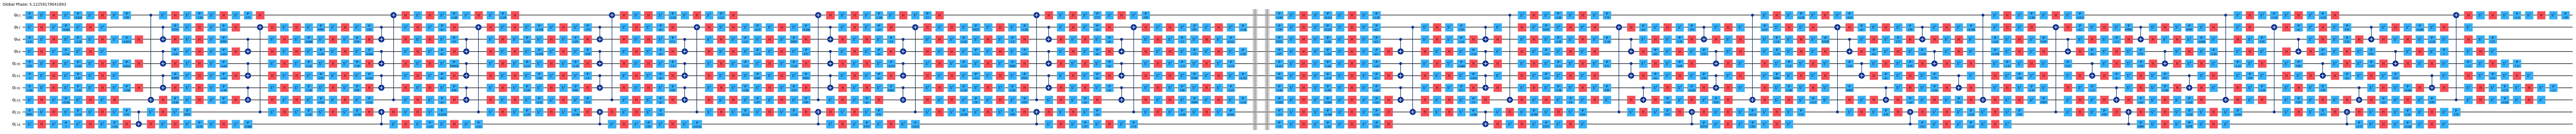

In [6]:
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager

# Generate the pass manager with optimization level 3
pm = generate_preset_pass_manager(backend=backend, optimization_level=3)
isa_circuit = pm.run(mirror_circuit)

# Visualize the decomposed circuit
isa_circuit.decompose().draw("mpl", scale=0.7,fold=-1,idle_wires=False)


The transpiled circuit now contains only ISA instructions. The single-qubit gates have been decomposed in terms of $\sqrt{X}$ gates and $R_z$ rotations, and the CX gates have been decomposed into [ECR gates](https://docs.quantum.ibm.com/api/qiskit/qiskit.circuit.library.ECRGate#ecrgate) and single-qubit rotations.

The transpilation process has mapped the virtual qubits of the circuit to physical qubits on the hardware. The information about the qubit layout is stored in the `layout` attribute of the transpiled circuit. The observable was also defined in terms of the virtual qubits, so you need to apply this layout to the observable, which you can do with the [`apply_layout`](https://docs.quantum.ibm.com/api/qiskit/qiskit.quantum_info.SparsePauliOp#apply_layout) method of `SparsePauliOp`.


In [7]:
# Get the isa observable using the pass manager
isa_observable = observable.apply_layout(isa_circuit.layout)
print("Original Observable:", observable)
print("ISA Observable:", isa_observable)

Original Observable: SparsePauliOp(['IIIIIIIIIZ'],
              coeffs=[1.+0.j])
ISA Observable: SparsePauliOp(['IIIIIIIIIIIIIIIIZIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIII'],
              coeffs=[1.+0.j])


## Step 3. Execute circuits using the Estimator primitive

You are now ready to run your circuit using the Estimator primitive.

Here you will submit six separate jobs, starting with no error suppression or mitigation, and successively enabling various error suppression and mitigation options available in Qiskit Runtime. For information about the options, refer to the following pages:

* [Overview of all options](https://docs.quantum.ibm.com/api/qiskit-ibm-runtime/options)
* [Dynamical decoupling](https://docs.quantum.ibm.com/api/qiskit-ibm-runtime/qiskit_ibm_runtime.options.DynamicalDecouplingOptions)
* [Resilience, including measurement error mitigation and zero-noise extrapolation (ZNE)](https://docs.quantum.ibm.com/api/qiskit-ibm-runtime/qiskit_ibm_runtime.options.ResilienceOptionsV2)
* [Twirling](https://docs.quantum.ibm.com/api/qiskit-ibm-runtime/qiskit_ibm_runtime.options.TwirlingOptions)
* [Probabilistic Error Cancellation](https://quantum.cloud.ibm.com/docs/en/guides/error-mitigation-and-suppression-techniques#probabilistic-error-cancellation-pec)

Because these jobs can run independently of each other, you can use [batch mode](https://docs.quantum.ibm.com/run/run-jobs-batch) to allow Qiskit Runtime to optimize the timing of their execution.


In [28]:

from qiskit_ibm_runtime import Batch, EstimatorV2 as Estimator

pub = (isa_circuit, isa_observable)

jobs = []

with Batch(backend=backend) as batch:
    estimator = Estimator(mode=batch)
    # Set number of shots
    estimator.options.default_shots = 100000
    # Disable runtime compilation and error mitigation
    estimator.options.resilience_level = 0

    # Run job with no error mitigation
    job0 = estimator.run([pub])
    jobs.append(job0)

    # Add dynamical decoupling (DD)
    estimator.options.dynamical_decoupling.enable = True
    job1 = estimator.run([pub])
    jobs.append(job1)

    # Add readout error mitigation (DD + TREX)
    estimator.options.resilience.measure_mitigation = True
    job2 = estimator.run([pub])
    jobs.append(job2)

    # Add gate twirling (DD + TREX + Gate Twirling)
    estimator.options.twirling.enable_gates = True
    estimator.options.twirling.num_randomizations = "auto"
    job3 = estimator.run([pub])
    jobs.append(job3)

    # Add zero-noise extrapolation (DD + TREX + Gate Twirling + ZNE)
    estimator.options.resilience.zne_mitigation = True
    job4 = estimator.run([pub])
    jobs.append(job4)

    # Add probabilistic error cancellation (PEC)
    # NOTE: PEC and ZNE cannot be enabled simultaneously
    estimator.options.resilience.zne_mitigation = False   # turn off ZNE
    estimator.options.resilience.pec_mitigation = True   # turn on PEC 

    # Optional PEC tuning knobs (PecOptions): max_overhead, noise_gain 
    estimator.options.resilience.pec.max_overhead = 100  # default is 100; set lower to cap cost
    estimator.options.resilience.pec.noise_gain = "auto" # default is "auto"

    job5 = estimator.run([pub])
    jobs.append(job5)


## Step 4. Post-process and return results in classical format

Finally, you can analyze the data. Here you will retrieve the job results, extract the measured expectation values from them, and plot the values, including error bars of one standard deviation.


/Users/jma/miniconda3/envs/3122/lib/python3.12/site-packages/qiskit/qpy/interface.py:384: UserWarning: The qiskit version used to generate the provided QPY file, 2.3.0, is newer than the current qiskit version 2.2.2. This may result in an error if the QPY file uses instructions not present in this current qiskit version
  warnings.warn(


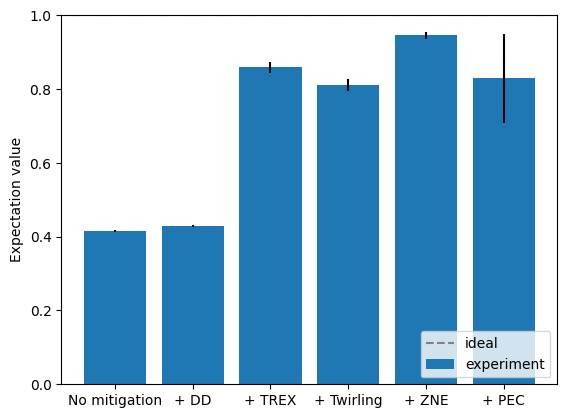

In [29]:
import matplotlib.pyplot as plt

# Retrieve the job results
results = [job.result() for job in jobs]

# Unpack the PUB results (there's only one PUB result in each job result)
pub_results = [result[0] for result in results]

# Unpack the expectation values and standard errors
expectation_vals = np.array([float(pub_result.data.evs) for pub_result in pub_results])
standard_errors = np.array([float(pub_result.data.stds) for pub_result in pub_results])

# Plot the expectation values
fig, ax = plt.subplots()
labels = ["No mitigation", "+ DD", "+ TREX", "+ Twirling", "+ ZNE", "+ PEC"]
ax.bar(range(len(labels)), expectation_vals, yerr=standard_errors, label="experiment")
ax.axhline(y=1.0, color="gray", linestyle="--", label="ideal")
ax.set_xticks(range(len(labels)))
ax.set_xticklabels(labels)
ax.set_ylabel("Expectation value")
ax.legend(loc="lower right")

plt.show()

At this small scale, it is difficult to see the effect of most of the error mitigation techniques, but zero noise extrapolation (ZNE) does give a noticeable improvement. On the other hand, note that probabilistic error cancellation (PEC) result has a larger error bar.


## Scale the experiment up

When developing an experiment, it's useful to start with a small circuit to make visualizations and simulations easier. Now that you've developed and tested our workflow on a 10-qubit circuit, you can scale it up to 50 qubits. The following code cell repeats all of the steps in this notebook, but now applies them to a 50-qubit circuit.


In [8]:
# Make the same exercise with a 50 qubit circuit

# Create a circuit that implements the Efficient SU2 ansatz with 50 qubits, 1 repetition and pairwise entanglement.
num_qubits = 50
circuit = efficient_su2(num_qubits=num_qubits, reps=1, entanglement='pairwise')
# Create the observable for 50 qubits
pauli_string = 'I' * (num_qubits - 1) + 'Z'
observable = SparsePauliOp(pauli_string)
# Create the mirror circuit for 50 qubits
rng = np.random.default_rng(1234)
params = rng.uniform(-np.pi, np.pi, size=circuit.num_parameters)
assigned_circuit = circuit.assign_parameters(params)
assigned_circuit.barrier()
mirror_circuit = unitary_overlap(assigned_circuit, assigned_circuit)
# Create the isa circuit for 50 qubits
pm = generate_preset_pass_manager(backend=backend, optimization_level=3)
isa_circuit = pm.run(mirror_circuit)


### Execute the circuit for 50 qubits

In [31]:
pub = (isa_circuit, isa_observable)

jobs = []

with Batch(backend=backend) as batch:
    estimator = Estimator(mode=batch)
    # Set number of shots
    estimator.options.default_shots = 100000
    # Disable runtime compilation and error mitigation
    estimator.options.resilience_level = 0

    # Run job with no error mitigation
    job0 = estimator.run([pub])
    jobs.append(job0)

    # Add dynamical decoupling (DD)
    estimator.options.dynamical_decoupling.enable = True
    # Set the sequence type
    estimator.options.dynamical_decoupling.sequence_type = "XpXm"
    job1 = estimator.run([pub])
    jobs.append(job1)

    # Add readout error mitigation (DD + TREX)
    estimator.options.resilience.measure_mitigation = True
    job2 = estimator.run([pub])
    jobs.append(job2)

    # Add gate twirling (DD + TREX + Gate Twirling)
    estimator.options.twirling.enable_gates = True
    estimator.options.twirling.num_randomizations = "auto"
    job3 = estimator.run([pub])
    jobs.append(job3)

    # Add zero-noise extrapolation (DD + TREX + Gate Twirling + ZNE)
    estimator.options.resilience.zne_mitigation = True
    # Set the noise factors
    # Set the extrapolators
    job4 = estimator.run([pub])
    jobs.append(job4)

    # Add probabilistic error cancellation (PEC)
    # NOTE: PEC and ZNE cannot be enabled simultaneously
    estimator.options.resilience.zne_mitigation = False   # turn off ZNE
    estimator.options.resilience.pec_mitigation = True   # turn on PEC 

    # Optional PEC tuning knobs (PecOptions): max_overhead, noise_gain 
    estimator.options.resilience.pec.max_overhead = 100  # default is 100; set lower to cap cost
    estimator.options.resilience.pec.noise_gain = "auto" # default is "auto"

    job5 = estimator.run([pub])
    jobs.append(job5)

### Post-process for 50 qubits

/Users/jma/miniconda3/envs/3122/lib/python3.12/site-packages/qiskit/qpy/interface.py:384: UserWarning: The qiskit version used to generate the provided QPY file, 2.3.0, is newer than the current qiskit version 2.2.2. This may result in an error if the QPY file uses instructions not present in this current qiskit version
  warnings.warn(


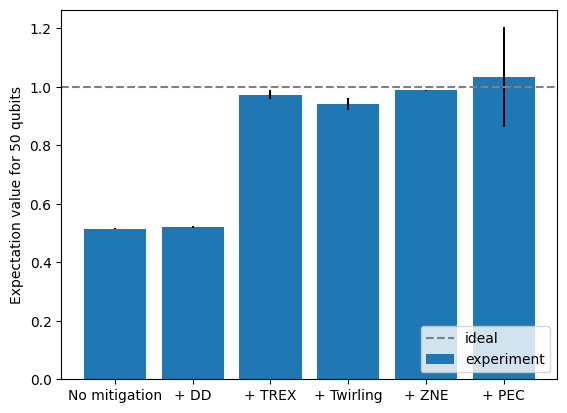

In [32]:
# Retrieve the job results
results = [job.result() for job in jobs]

# Unpack the PUB results (there's only one PUB result in each job result)
pub_results = [result[0] for result in results]

# Unpack the expectation values and standard errors
expectation_vals = np.array([float(pub_result.data.evs) for pub_result in pub_results])
standard_errors = np.array([float(pub_result.data.stds) for pub_result in pub_results])

# Plot the expectation values
fig, ax = plt.subplots()
labels = ["No mitigation", "+ DD", "+ TREX", "+ Twirling", "+ ZNE", "+ PEC"]
ax.bar(range(len(labels)), expectation_vals, yerr=standard_errors, label="experiment")
ax.axhline(y=1.0, color="gray", linestyle="--", label="ideal")
ax.set_xticks(range(len(labels)))
ax.set_xticklabels(labels)
ax.set_ylabel("Expectation value for 50 qubits")
ax.legend(loc="lower right")

plt.show()

When you compare the 50-qubit results with the 10-qubit results from earlier, you might note the following (your results might differ across runs):

* The results without error mitigation are worse. Running the larger circuit involves executing more gates, so there are more opportunities for errors to accumulate.
* The addition of dynamical decoupling might have worsened performance. This is not surprising, because the circuit is very dense. Dynamical decoupling is primarily useful when there are large gaps in the circuit during which qubits sit idle without gates being applied to them. When these gaps are not present, dynamical decoupling is not effective, and can actually worsen performance due to errors in the dynamical decoupling pulses themselves. The 10-qubit circuit may have been too small for us to observe this effect.
* With zero-noise extrapolation, the result is as good, or nearly as good, as the 10-qubit result. This demonstrates the power of the ZNE technique!
* The probabilistic error cancellation (PEC) technique is giving a much better result than in the 10 qubit scenario. However further tuning of the parameters is needed to perform as good as ZNE in this specific circuit.
* If you want to learn more about these techniques you can check out [this material](https://github.ibm.com/Coding-Challenges-Squad/QGSS-2025-labs/blob/main/lab-2/Lab2_sol.ipynb) about transpilation and error mitigation

## Conclusion

In this notebook, you investigated different error mitigation options available for the Qiskit Runtime Estimator primitive. You developed a workflow using a 10-qubit circuit, and then scaled it up to 50 qubits. You might have observed that enabling more error suppression and mitigation options doesn't always improve performance (specifically, enabling dynamical decoupling in this case). Most of the options accept additional configuration, which you can test out in your own work!


## Bonus: Error suppression and mitigation using the Sampler

The Qiskit Runtime Sampler primitive does not support error mitigation techniques yet. However it supports error suppression techniques and we are going to test how you can use them to try to prevent errors from occurring. To apply error mitigation for sampling we will use later the M3 Qiskit Addon.

First, we will apply dynamical decoupling and twirling options.

### Create the 50 qubits circuit for the Sampler

In [9]:
# Create a circuit that implements the Efficient SU2 ansatz with 50 qubits, 1 repetition and pairwise entanglement.
mirror_circuit.measure_all()
# Create the isa circuit for 50 qubits
pm_sampler = generate_preset_pass_manager(backend=backend, optimization_level=3)
isa_circuit_sampler = pm_sampler.run(mirror_circuit)

### Execute the circuit for 50 qubits using Error Suppression

In [ ]:
from qiskit_ibm_runtime import SamplerV2 as Sampler

# Create primitive input
pub = isa_circuit_sampler  # Just the circuit, no observable for Sampler

jobs_sampler = []

with Batch(backend=backend) as batch:
    sampler = Sampler(mode=batch)
    
    # Set number of shots
    sampler.options.default_shots = 100000

    # Run with no error mitigation
    job0_sampler = sampler.run([pub])
    jobs_sampler.append(job0_sampler)

    # Enable gate twirling
    sampler.options.twirling.enable_gates = True
    sampler.options.twirling.num_randomizations = "auto"
    job1_sampler = sampler.run([pub])
    jobs_sampler.append(job1_sampler)

    # Enable dynamical decoupling (DD) in addition to gate twirling
    sampler.options.dynamical_decoupling.enable = True
    sampler.options.dynamical_decoupling.sequence_type = "XpXm"
    job2_sampler = sampler.run([pub])
    jobs_sampler.append(job2_sampler)



# After the batch, retrieve the results
results_sampler = [job_sampler.result() for job_sampler in jobs_sampler]


### Post-process for 50 qubits

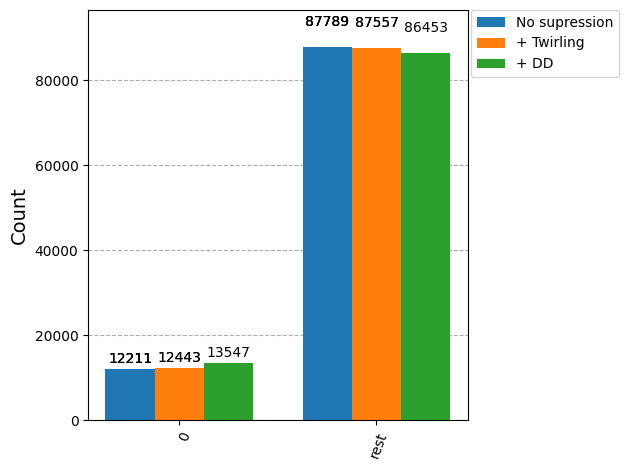

In [ ]:
def convert_keys_to_decimal(counts_dict):
    return {int(bitstring, 2): count for bitstring, count in counts_dict.items()}
# Extract  counts
counts_list= [res[0].data.meas.get_counts() for res in results_sampler]
# Convert binary keys to decimal
decimal_counts_list = [convert_keys_to_decimal(d) for d in counts_list]

from qiskit.visualization import plot_histogram

# Labels for each configuration
labels = ["No suppression", "+ Twirling", "+ DD",]

# Plot all histograms together
plot_histogram(decimal_counts_list, number_to_keep=1, legend=labels)

In this plot, we can observe two key points:

First, the application of error suppression techniques (DD and gate twirling) clearly increases the probability of measuring the $|0\rangle^{\otimes n}$ state compared to all other states. This indicates that these techniques are effectively supressing the noise and improving the performance.

Second, we notice something that might seem counterintuitive at first: for the case of $n = 50$ qubits, the total counts for non-$|0\rangle^{\otimes n}$ states actually exceed those of the $|0\rangle^{\otimes n}$ state. However, this behavior is actually expected. In such a large Hilbert space (of dimension $2^{50}$) even low levels of noise can populate a vast number of excited states, making it common to see many non-zero bitstrings in the measurements. Still, the $|0\rangle^{\otimes n}$ state remains the most probable state, standing out clearly from the rest.

To confirm this, we can plot the 10 most frequently measured quantum states in the case without error suppression.

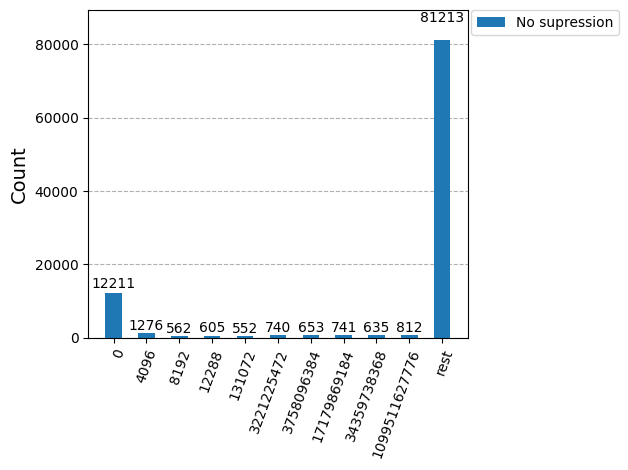

In [87]:
plot_histogram(decimal_counts_list[0], number_to_keep=10, legend=["No supression"])

As we were expecting, the $|0\rangle^\otimes{n}$ state is the most frequently observed outcome. The presence of counts for other states is due to noise in the quantum device. However, the noise level is not too severe, as we are still able to clearly identify the most probable quantum state.

## Using M3 readout mitigation method


The M3 ([Matrix‑free Measurement Mitigation](https://qiskit.github.io/qiskit-addon-mthree/)) method is a scalable approach to readout error mitigation that avoids constructing the full $2^n \times 2^n$ assignment matrix by using simplified models of readout errors. It assumes that correlations of order three and higher are negligible, which allows it to rely only on single-qubit and two-qubit assignment matrices obtained by preparing all qubits in the $\lvert 0\ldots0\rangle$ and $\lvert 1\ldots1\rangle$ states and measuring their error rates. These small $2\times2$ and $4\times4$ matrices are stored and later combined to form an effective mitigation matrix that is built only from the bitstrings observed during sampling. Because the size of this effective matrix grows with the number of sampled outcomes rather than $2^n$, M3 can be applied to circuits with much longer bitstrings than traditional linear algebra methods.

Now we are going to see how we can use it to reduce the error in the previous sampling exercise. For a more in-depth analysis check it out [here](https://quantum.cloud.ibm.com/docs/en/tutorials/readout-error-mitigation-sampler).

You might need to install this Qiskit Addon uncommenting the following line.

In [ ]:
# %pip install mthree

We now repeat the same workflow as above, but with M3 calibration integrated into the job preparation stage, so that all jobs are properly calibrated before execution on the quantum device.

In [ ]:
# M3 imports 
import mthree
import mthree.utils as m3utils

# Determine which physical qubits correspond to measured classical bits
# This list is ordered so that element i is the physical qubit that produced classical bit i.

meas_map = m3utils.final_measurement_mapping(isa_circuit_sampler)

with Batch(backend=backend) as batch:
    sampler = Sampler(mode=batch)

    # Set number of shots for your circuit sampling
    sampler.options.default_shots = 100000

    # Build mitigator and run M3 calibration inside same Batch 
    mit = mthree.M3Mitigation(backend)
    mit.cals_from_system(meas_map, shots=5000, runtime_mode=batch) 

    # Run with no error suppression
    job0_sampler = sampler.run([pub])
    jobs_sampler.append(job0_sampler)

    # Enable gate twirling
    sampler.options.twirling.enable_gates = True
    sampler.options.twirling.num_randomizations = "auto"
    job1_sampler = sampler.run([pub])
    jobs_sampler.append(job1_sampler)

    # Enable dynamical decoupling (DD) in addition to gate twirling
    sampler.options.dynamical_decoupling.enable = True
    sampler.options.dynamical_decoupling.sequence_type = "XpXm"
    job2_sampler = sampler.run([pub])
    jobs_sampler.append(job2_sampler)

# After the batch, retrieve the results
results_sampler = [job_sampler.result() for job_sampler in jobs_sampler]
counts_list = [res[0].data.meas.get_counts() for res in results_sampler]

# Apply M3 correction to each result 
# Returns quasi-probabilities (may contain small negative values)
m3_quasis = [mit.apply_correction(cnts, meas_map) for cnts in counts_list] 
m3_dicts = [dict(q) for q in m3_quasis]

labels_m3  = ["M3(No suppression)", "M3(+ Twirling)", "M3(+ DD)"]

# Convert binary keys to decimal
decimal_m3_dicts = [convert_keys_to_decimal(d) for d in m3_dicts]

In [ ]:
shots = 100000
def convert_counts_list(list_of_dicts, shots=100000):
    return [
        {int(k): (int(round(float(v) * shots)) if float(v) >= 0 else 0)
         for k, v in d.items()}
        for d in list_of_dicts
    ]
decimal_m3_dicts_converted = convert_counts_list(decimal_m3_dicts, shots=shots)

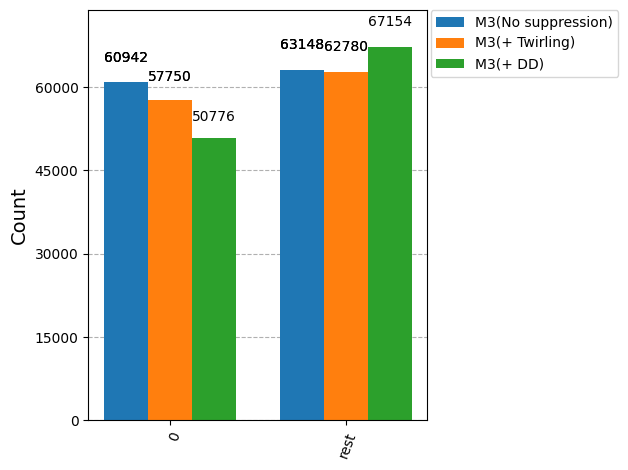

In [30]:
plot_histogram(decimal_m3_dicts_converted, number_to_keep=1, legend=labels_m3)


We can see that using the M3 Qiskit Addon significantly improves the results compared to the previous case without mitigation. In particular, the probability of measuring the state $ |0\rangle^{\otimes n} $ exceeds 50\%, which is substantially higher than in the previous histogram above.

On the other hand, once M3 error mitigation is applied, the effect of the suppression techniques becomes much less important, and they do not lead to further improvements in the final results.